In [1]:
import matplotlib.pyplot as plt
import numpy             as np
import scipy.io.wavfile  as siw
import sys
import copy

In [2]:
# ------------------------- read in and setup-----------------------------

# Read in sound file, which is a (mono) wave file; the primary information 
# gets stored in these pieces:
#    rate : sampling rate (units of Hz)
#    data : 1- or 2-D array of time series.
#           In the case of a 2D array, we need to transpose for dimensions
#    N    : how many time points in the data storage array
infile_wav  = '07062015_lions_mono_short.wav'
rate, data  = siw.read(infile_wav)
N           = len(data)

# prepare for output, by determining a couple useful pieces of information
#    dtype_dat : what 'dtype' does wave file data have?
#    out_base  : make a 'base name' for the output file
dtype_dat   = data.dtype.name      # 
out_base    = infile_wav.replace('.wav', '') 

# ***** check the values of the items made above, to know what they are
rate

44100

In [3]:
data, N

(array([   0,    0,   -1, ..., -243, -229, -170], dtype=int16), 882000)

In [4]:
dtype_dat

'int16'

In [5]:
out_base

'07062015_lions_mono_short'

In [6]:
# plt.plot?

/home/guest/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1762: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/home/guest/anaconda3/lib/python3.12/site-packages/matplotlib/cbook.py:1398: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


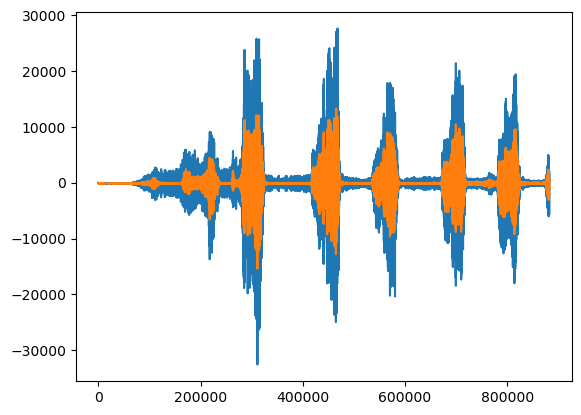

In [29]:
# ------------------------- do processing -----------------------------

# example of copying the data
x = copy.deepcopy(data)
X = np.fft.fft(x)

# ***** make a plot!
# plt.plot(x)
# plt.show()
# ***** process! Use FFT, then create a LOW PASS FILTER to try to 
# eliminate the high frequency sounds, then use IFFT to get a new
# time series
# -> then plot this, and save it out to a file, as shown below

h = np.zeros(N)
cut = 40_000

h[:cut] = 1

C = X*h

c = np.fft.ifft(C)

plt.plot(data)
plt.plot(c)

In [30]:
# Xk = np.fft.fft(x, norm='forward')
# # Xk = np.fft.fftshift(Xk)

In [31]:
# plt.plot(np.abs(Xk))
# plt.title('Plot of Fourier Coefficients of input signal')
# plt.xlabel('t')
# plt.ylabel('Amplitude')
# plt.grid()
# plt.show()

In [32]:
# # h = np.zeros(N, dtype=float)
# # h[:100000] = 1/(100_000)

# val = 40_000

# F = np.zeros(N)
# F[:val] = 1
# # F[N-val:] = 1/(val)

# C = Xk * F
# c = np.real(np.fft.ifft(C))

# plt.plot(N,data)
# plt.plot(N, c)

In [33]:
# Hk = np.fft.fft(h, norm='forward')
# plt.plot(F)
# # plt.plot(Xk)
# plt.show()

In [19]:
# plt.plot(np.abs(Hk))
# plt.show()

In [34]:
# Xnew = Xk*F

# xnew = np.real(np.fft.ifft(Xnew))

In [35]:
# fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(12,4))
# plt.plot(np.abs(xnew), label='')
# plt.plot(np.abs(Xk))

# plt.show()

In [36]:
# N

In [37]:
# filtered_x = np.fft.ifft(Xnew, norm='forward')

In [168]:
# xfilter = np.fft.ifft(Xk, norm='forward')

In [38]:
# fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(16,5))

# ax[0].plot(x[:500], label='x')
# ax[1].plot(np.real(filtered_x[:500]), label='filtered_x', alpha=0.5)
# ax[0].legend()
# ax[1].legend()
# plt.show()

In [40]:
# ---------------------- output wav files -----------------------------


# example of writing out the original wave: make an output name, and
# provide correct sampling rate and dtype for writing data
out_file = out_base + '_x.wav'
siw.write(out_file, rate, x.astype(dtype_dat))


# ***** write some more output
out_file = 'new' + '_x.wav'
siw.write(out_file, rate, c.astype(dtype_dat))


# celebrate
print("Done!")

Done!


/tmp/ipykernel_47587/2992302248.py:12: ComplexWarning: Casting complex values to real discards the imaginary part
  siw.write(out_file, rate, c.astype(dtype_dat))


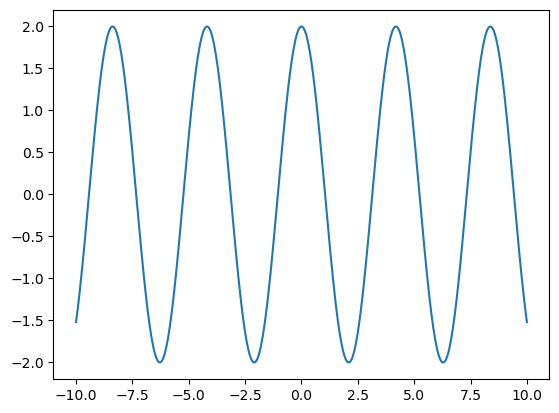

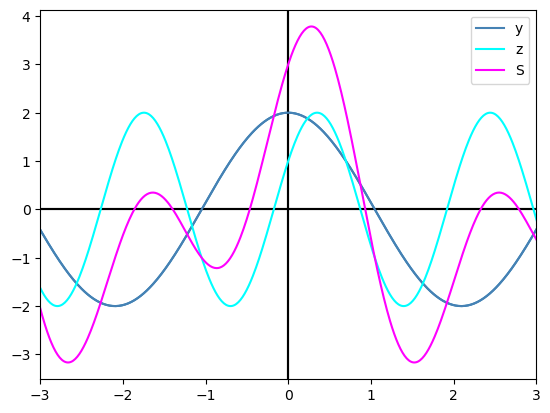

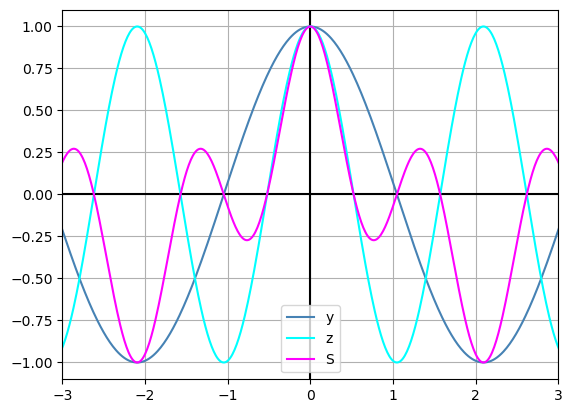

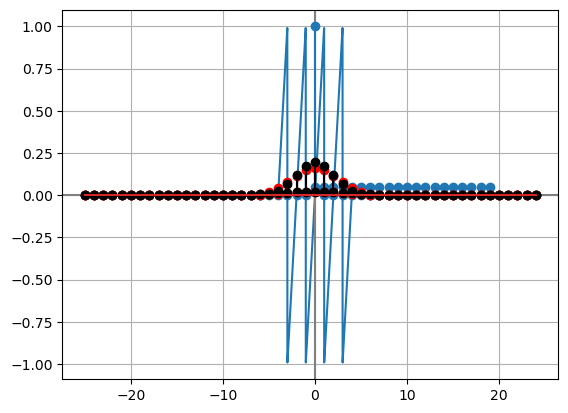

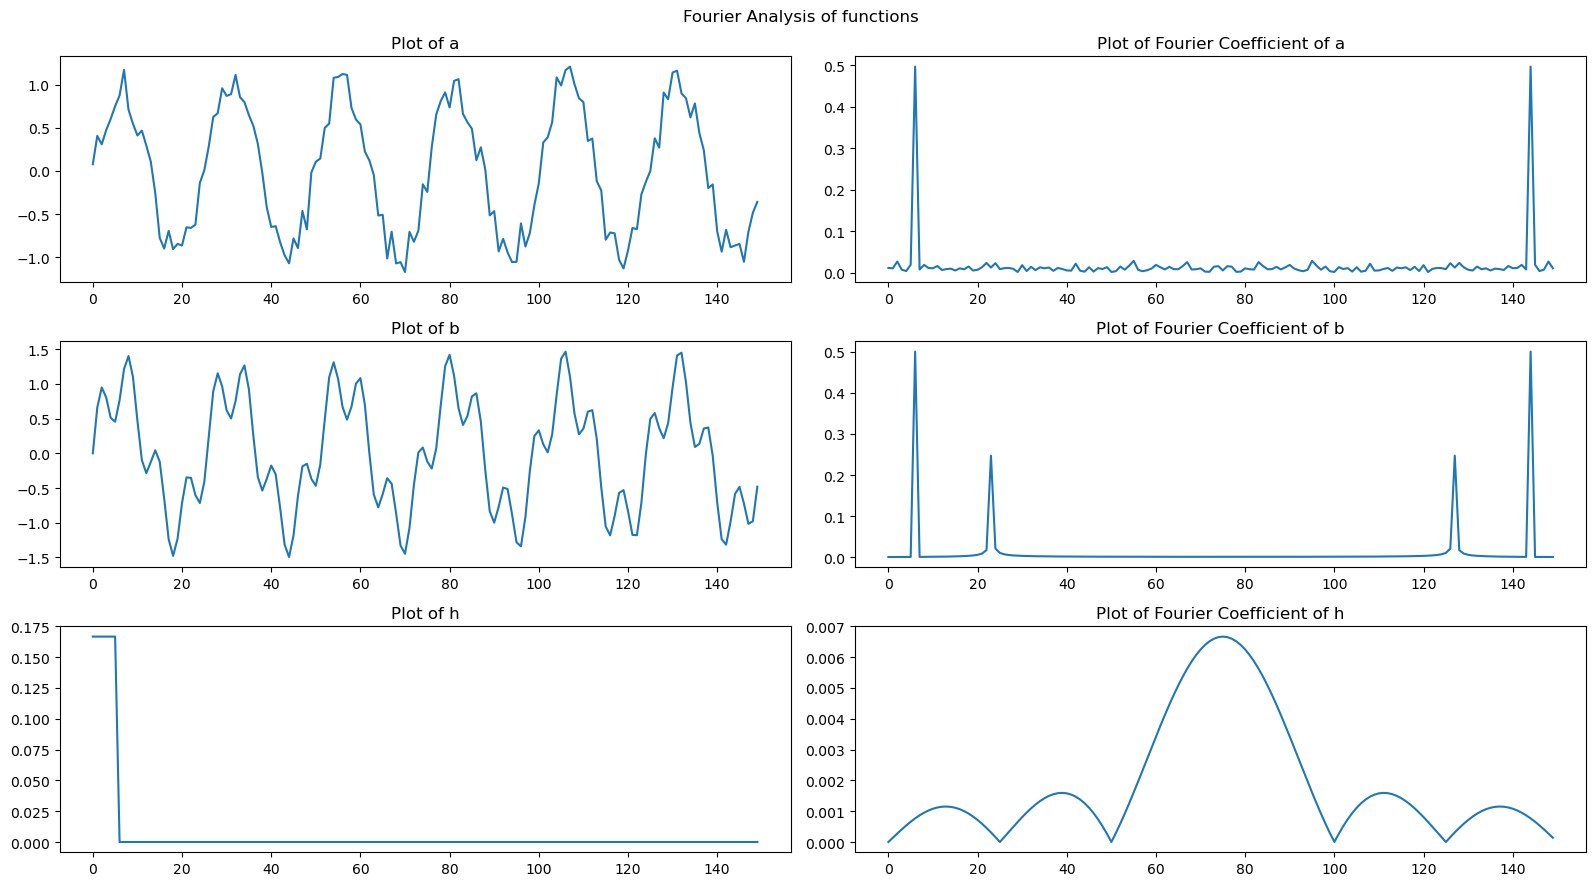

/tmp/ipykernel_47587/934411072.py:260: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax[i, 1].legend()


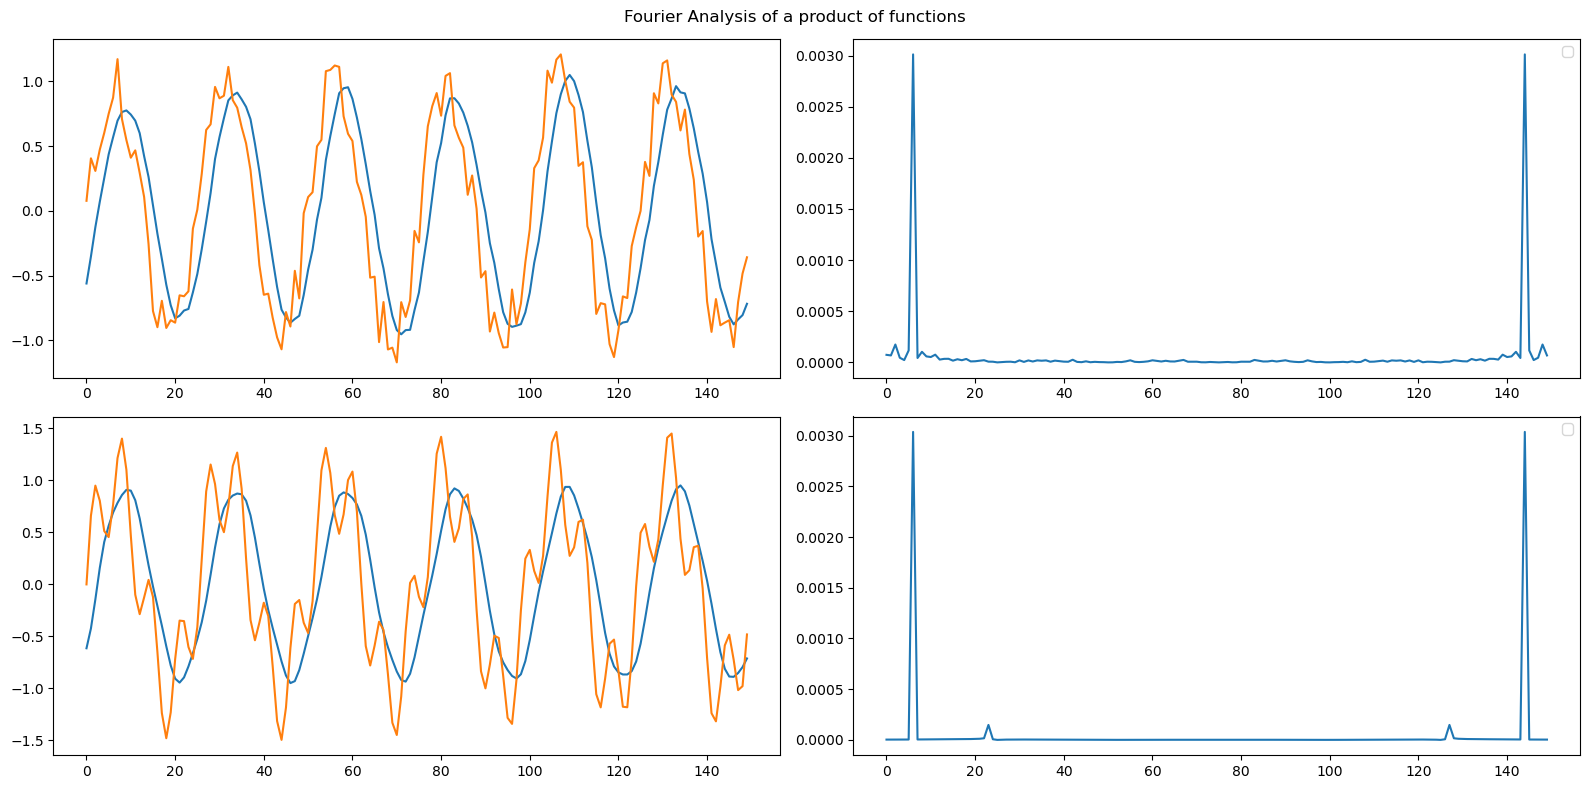

Type:        module
String form: <module 'numpy.fft' from '/home/guest/anaconda3/lib/python3.12/site-packages/numpy/fft/__init__.py'>
File:        ~/anaconda3/lib/python3.12/site-packages/numpy/fft/__init__.py
Docstring:  
Discrete Fourier Transform (:mod:`numpy.fft`)

.. currentmodule:: numpy.fft

The SciPy module `scipy.fft` is a more comprehensive superset
of ``numpy.fft``, which includes only a basic set of routines.

Standard FFTs
-------------

.. autosummary::
   :toctree: generated/

   fft       Discrete Fourier transform.
   ifft      Inverse discrete Fourier transform.
   fft2      Discrete Fourier transform in two dimensions.
   ifft2     Inverse discrete Fourier transform in two dimensions.
   fftn      Discrete Fourier transform in N-dimensions.
   ifftn     Inverse discrete Fourier transform in N dimensions.

Real FFTs
---------

.. autosummary::
   :toctree: generated/

   rfft      Real discrete Fourier transform.
   irfft     Inverse real discrete Fourier transform.
 

In [49]:
## <strong><center>Day 01 - Sinusoids</center></strong>

import numpy as np
import matplotlib.pyplot as plt

# Plot the following function:
###  $y = A \cos{(\omega t - \phi)}$

x = np.linspace(-10, 10, 501)
A = 2.0
w = 1.5
phi = 0

def f(A, w, phi, t):
    return A*(np.cos(w*t - phi))

f1 = f(A, w, phi, x)
# f2 = f(1, 1, 1, x)

plt.plot(x, f1)
# plt.plot(x, f2)
plt.show()

## lecturer code:
N = 501
t = np.linspace(-np.pi, np.pi, N) # initialize t
y = np.zeros(N, dtype=float) # initialize y
z = np.zeros(N, dtype=float) # initialize z
S = np.zeros(N, dtype=float) # initialize z

A = 2.0
omega = 1.5
phi = 0

for i in range(0, N):
    y[i] = A*np.cos(omega*t[i] - phi)

plt.plot(t, y);
# plt.grid()
plt.axhline(c='black')
plt.axvline(c='black')

# -----------

## <strong><center>Day 02 - Sinusoids</center></strong>

A2 = 2
omega2 = 3 
phi2 = np.pi/3

for i in range(0, N):
    y[i] = A*np.cos(omega*t[i] - phi)
    z[i] = A2*np.cos(omega2*t[i] - phi2)
    S[i] = y[i] + z[i]

# plt.grid()
plt.axhline(c='black')
plt.axvline(c='black')
plt.plot(t, y, c='steelblue', label='y')
# plt.plot(z, y)
plt.plot(t, z, c='cyan', label='z')
plt.plot(t, S, c='magenta', label='S')
plt.xlim([-3,3])
plt.legend()
plt.show()

A2 = 1
omega2 = 3 
phi2 = 0


A = 1
omega = 1.5
phi = 0

for i in range(0, N):
    y[i] = A*np.cos(omega*t[i] - phi)
    z[i] = A2*np.cos(omega2*t[i] - phi2)
    S[i] = y[i]*z[i]

# plt.grid()
plt.axhline(c='black')
plt.axvline(c='black')
plt.plot(t, y, c='steelblue', label='y')
# plt.plot(z, y)
plt.plot(t, z, c='cyan', label='z')
plt.plot(t, S, c='magenta', label='S')
plt.xlim([-3,3])
plt.grid()
plt.legend()
plt.show()



### Area under the red curve

#We're going to use the Riemann approximation method over here to get the area under the curve

delta_t = t[1]-t[0]
sum_S = np.sum(S)
area_S = sum_S*delta_t

area_S

# -----

## <strong><center>Day 03 - Fourier Series</center></strong>


# Given the function $x(t) = \begin{cases}\frac{2}{T_0}t& -\frac{T_0}{2}\le t\le \frac{T_0}{2}\\\text{and repeat}\end{cases}$ we find the Fourier series expression for it.

T0 = 2
w0 = (2 * np.pi)/T0
N = 10001
t = np.linspace(-2*T0, 2*T0, N)
kmax = 10000
x = np.zeros(N, dtype=float)

for k in range(1, kmax+1):
    x += (-2/np.pi)*(((-1)**k)/k)*np.sin(k*w0*t)

x

plt.plot(t, x)
plt.axhline(c='0.5')
plt.axvline(c='0.5')

# <center>Discrete Time Fourier Transforms</center>

# $$x[n]=\begin{cases}1& n=mN_0\\0&\text{else}\end{cases}$$

# This is the "periodic" Dirac-delta. FFT is one of the most important formulas of the twenty-first century.

import numpy as np

N = 51
t = np.arange(-25, 26)
x = np.zeros(N, dtype=float)


x[(N+1)//2] = 1

for i in range(N):
    if (i-((N+1)//2))%10==6:
        x[i]=1

import matplotlib.pyplot as plt



N0 = 20
n = np.arange(-N0//2, -N0//2+N0)
N = len(n)
x = np.zeros(N, dtype=float)

# for i in range(N):
#     if (n[i])%N0 == 0:
#         x[i] = 1
x[N0//2] = 1
# x = np.arange(N0//2)

plt.stem(n, x)
# plt.yticks(x)
plt.grid()

np.fft?

# $$A_k =  \sum_{m=0}^{n-1} a_m \exp\left\{-2\pi i{mk \over n}\right\}
   # \qquad k = 0,\ldots,n-1.$$

# Our ANALYSIS equation: the FFT, using forward normalization
X = np.fft.fft(x, norm='forward')

X

len(X)

k = np.arange(0, N0)
plt.stem(k, np.abs(X))

# This is for the gaussian distribution.

N0 = 50
n = np.arange(-N0//2, (-N0//2)+N0)
sigma = 2.5
sigma2 = 2
x = (1.0/np.sqrt(2*np.pi*sigma**2))*np.exp(-0.5*n*n/sigma/sigma)
y = (1.0/np.sqrt(2*np.pi*sigma2**2))*np.exp(-0.5*n*n/sigma2/sigma2)
X = np.fft.fft(x, norm='forward')
Y = np.fft.fft(y, norm='forward')
Xsh = np.fft.fftshift(X)
Ysh = np.fft.fftshift(Y)
ksh = np.arange(-N0//2, (-N0//2)+N0)

plt.stem(n, x, linefmt='red')
plt.stem(n, y, linefmt='black')

plt.stem(ksh, np.abs(Xsh), linefmt='red')
plt.stem(ksh, np.abs(Ysh), linefmt='black')

# <center>Tutorial Three</center>

## <center>$a[n] = \sin\left(\frac{2\pi n}{25}\right)+\frac{1}{2}(\operatorname{rand}(1)-0.5)$</center>
## <center>$b[n] = \sin\left(\frac{2\pi n}{25}\right)+\frac{1}{2}\sin\left(\frac{2\pi n}{6.5}\right)$</center>
## <center>$h[n] = \begin{cases}\frac{1}{6}&n<6\\0&\text{ else}\end{cases}$</center>


# rand --- uniformly distributed number between [0,1)
# <br><br>
# 0 <= n < 150

import numpy as np
import matplotlib.pyplot as plt
# dir(np.random)

N = 150

n = np.arange(N)
# k = np.arange
a = np.sin((2*np.pi*n)/25) + 0.5*(np.random.rand(150)-0.5)
b = np.sin((2*np.pi*n)/25) + 0.5*(np.sin((2*np.pi*n)/6.5))
h = n
h = np.array([1/6 if i < 6 else 0 for i in n])

A = np.fft.fft(a, norm='forward')
B = np.fft.fft(b, norm='forward')
H = np.fft.fft(h, norm='forward')
Hsh = np.fft.fftshift(H)

fig, ax = plt.subplots(nrows=3, ncols=2, figsize=(16, 9))
left_col = {'a':a,'b':b,'h':h}
right_col = {'a':A,'b':B,'h':Hsh}


for i, (lab, fun) in enumerate(left_col.items()):
    ax[i,0].plot(n, fun)
    ax[i,0].set_title(f'Plot of {lab}')
    ax[i,1].plot(n, np.abs(right_col[lab]))
    ax[i,1].set_title(f'Plot of Fourier Coefficient of {lab}')

plt.suptitle('Fourier Analysis of functions')
plt.tight_layout()
plt.show()

C = A*H
D = B*H

c = np.fft.ifft(C, norm='forward')
d = np.fft.ifft(D, norm='forward')

fig, ax = plt.subplots(nrows=2, ncols=2, figsize=(16,8))

left_colnew = {'a':c, 'b':d}
right_col = {'a':C,'b':D}

for i, (lab, fun) in enumerate(right_col.items()):
    ax[i, 0].plot(n, N*np.real(left_colnew[lab]))
    ax[i, 0].plot(n, left_col[lab])
    ax[i, 1].plot(n, np.abs(right_col[lab]))
    ax[i, 1].legend()

plt.suptitle('Fourier Analysis of a product of functions')
plt.tight_layout()
plt.show()

# 1. Classification into homogenous and distinct groups.
# 2. Unsupervised algorithm.
# 3. Useful in many fields like social sciences and biology.
# 4. Distance measure.
# 5. Statistical Method

# Statistical methods allow experts to retrieve information from large amounts data. One of such methods is cluster analysis. Cluster analysis is a method of information retrieval that allows us partition data into distinct groups where the data points are homogeneous. It is an unsupervised learning algorithm in that the number of clusters to be determined are not defined before the start of the algorithm. What needs to be defined prior to analysis, however, is a distance measure which helps us define what "similarity" between data points mean. In this way, cluster analysis is different from classification analysis, another statistical method which does not make use of a predefined distance measure. 
# Cluster analysis is useful in different domains like in marketing. For example, companies may be interested in segmenting their customer base in order to develop targeted products for each groups.

